# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [62]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [63]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [64]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [65]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [66]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [67]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [68]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [69]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [70]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Para el dataset de "users" se tiene dos columnas con datos faltantes; city con un 11.7% de datos faltantes, y "churn_date" con un 88.3% de datos faltantes.
- En el caso del dataser "usage" se tiene 3 columnas con faltantes; date con un 0.125%, duration con 55.19% y lenght con 44.7%
- Indica qué harías: ¿imputar, eliminar, ignorar?
-Para la columna date del dataset "usage" solo haría una imputación con la mediana.
-Para las columnas churn_date la mantendría pero sin imputar porque representa usuarios activos.
-Y las columnas duration y lenght tendría que evaluar si aportan valor o no. No las imputaría.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [71]:
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` tiene un std demasiado alto.
- La columna `age` tiene valores mínimos negativos.

In [72]:
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` tienen como valores máximos un valor muy alto (120 y 1490) pero el 75% de ellos están muy por debajo de ellos (7 y 64 re4spectivamente). Se tendría que revisar si son sentinels.
- Las columnas id y user_id están bien. No necesitan limpieza.

In [73]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nColumna: {col}")
    print(users[col].unique())




Columna: city
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Columna: plan
['Basico' 'Premium']


- La columna `city`tiene datos faltantes represntados con "?" y nan.
- La columna `plan` está completa y nos muestra qué tipos de plan tiene cada usuario con respecto al df de "plans"

In [74]:
# explorar columna categórica de usage
usage['type'].unique


<bound method Series.unique of 0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object>

- La columna `type` nos indica uqé tipo de interacción se tuvo con el cliente, si fue text o fue call.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- En la columna "city".
- ¿Qué acción tomarías?
- Los sentinels los marcaría como NaN para poder tratarlo como dato faltante. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [75]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = 'coerce')


In [76]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [77]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, no se tiene el año 2025 y los datos del 2026 aún no han sucecido.

In [78]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, el valor 2024. se tendría que cambiar a 2024 y mantener los NaN.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- No. Todos los años son actuales, o sea no son de más de 5 años atrás.
- ¿Qué harías con ellas?
- Para los años que aún no han transcurrido y si solo son pocos valores podría eliminarlos o convertirlos a NaN.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [102]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [80]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios

users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [81]:
#users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['reg_date'] = users['reg_date'].mask(users['reg_date'].dt.year > 2024, pd.NA)
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

In [82]:
users['reg_date'].min()

Timestamp('2022-01-01 00:00:00')

In [83]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [84]:
# Verificación MAR en usage (Missing At Random) para duration
print("Missing duration por tipo de llamada:")
usage["duration"].isna().groupby(usage["type"]).mean()

Missing duration por tipo de llamada:


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [85]:
usage[usage["duration"].isna()]

,id,user_id,type,date,duration,length
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
8,9,11530,text,2024-01-01 00:52:07.758193954,NaN,44.0
9,10,12850,text,2024-01-01 00:58:38.727968199,NaN,70.0
11,12,10824,text,2024-01-01 01:11:40.667516687,NaN,31.0
...,...,...,...,...,...,...
39979,39980,13582,text,2024-06-29 21:49:40.604515112,NaN,41.0
39981,39982,11256,text,2024-06-29 22:02:42.544063600,NaN,48.0
39985,39986,11966,text,2024-06-29 22:28:46.423160578,NaN,58.0
39987,39988,11232,text,2024-06-29 22:41:48.362709066,NaN,52.0


In [86]:

df2 = usage[usage["duration"].notnull()]
df2.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN
5,6,10473,call,2024-01-01 00:32:34.848871221,4.68,NaN
6,7,12856,call,2024-01-01 00:39:05.818645466,3.27,NaN


In [87]:
df2["type"].isna().sum()

0

In [88]:
# Verificación MAR en usage (Missing At Random) para length

print("Missing length por tipo de llamada:")
usage["length"].isna().groupby(usage["type"]).mean()

Missing length por tipo de llamada:


type
call    0.99933
text    0.00000
Name: length, dtype: float64

In [89]:
usage[usage["length"].isna()]

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN
5,6,10473,call,2024-01-01 00:32:34.848871221,4.68,NaN
6,7,12856,call,2024-01-01 00:39:05.818645466,3.27,NaN
...,...,...,...,...,...,...
39994,39995,12418,call,2024-06-29 23:27:25.151128778,1.61,NaN
39995,39996,13497,call,2024-06-29 23:33:56.120903022,5.75,NaN
39996,39997,10941,call,2024-06-29 23:40:27.090677266,3.06,NaN
39997,39998,13038,call,2024-06-29 23:46:58.060451510,8.74,NaN


In [90]:
df3 = usage[usage["length"].notnull()]
df3.head()

,id,user_id,type,date,duration,length
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
8,9,11530,text,2024-01-01 00:52:07.758193954,NaN,44.0
9,10,12850,text,2024-01-01 00:58:38.727968199,NaN,70.0
11,12,10824,text,2024-01-01 01:11:40.667516687,NaN,31.0


In [91]:
df3['type'].isna().sum()

0

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
De acuerdo a lo obtenido, podemos identificar que en la columna de 'duration', solo nos mostrara nulos si es que en la columna 'type' aparece como 'text' ya que no se tiene una duración del texto, o sea, marcado en segundos, minutos u horas. Y en cuanto a la columna 'lenght' muestra nulos cuando en 'type' aparece como 'call'. Entonces, contestando la pregunta inicial, sí hay dependencia de nulos en estas columnas dependiendo de si muestra 'call' o 'text'.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [92]:
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes 
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

usage_agg = (
    usage
    .groupby('user_id')
    .agg({
        'is_text': 'sum',
        'is_call': 'sum',
        'duration': 'sum'
    })
    .reset_index()
)
# observar resultado 
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [93]:

# Renombrar columnas
user_profile = users.merge(usage_agg, on="user_id", how="left")

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [94]:


# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_text,is_call,duration
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [95]:
# Resumen estadístico de las columnas numéricas
num_cols = ["is_text", "is_call", "duration"]
resume = user_profile[num_cols].describe().T
resume["median"] = user_profile[num_cols].median()
resume


,count,mean,std,min,25%,50%,75%,max,median
is_text,3999.0,5.524381,2.358416,0.0,4.00,5.00,7.000,17.00,5.00
is_call,3999.0,4.478120,2.144238,0.0,3.00,4.00,6.000,15.00,4.00
duration,3999.0,23.317054,18.168095,0.0,11.12,19.78,31.415,155.69,19.78


In [96]:
# Distribución porcentual del tipo de plan
dist_plan = (
    user_profile["plan"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

dist_plan


Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

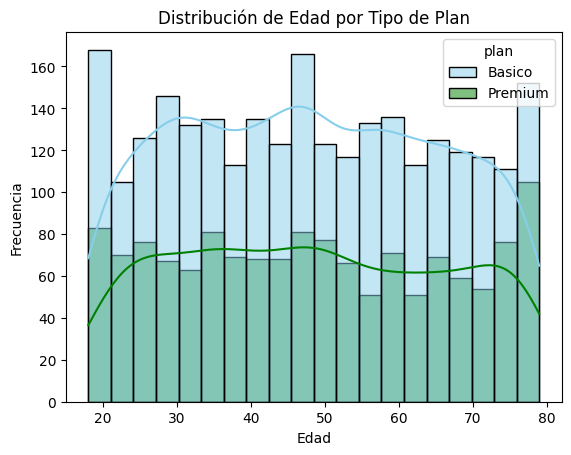

In [97]:

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20
)
plt.title("Distribución de Edad por Tipo de Plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()


💡Insights: 
- Los usuarios del plan Premium tienden a concentrarse ligeramente en edades mayores, mientras que el plan Básico muestra una distribución más uniforme.
- La distribución es ligeramente sesgada a la derecha si hay más usuarios jóvenes, o simétrica si está balanceada (depende de tus datos reales).


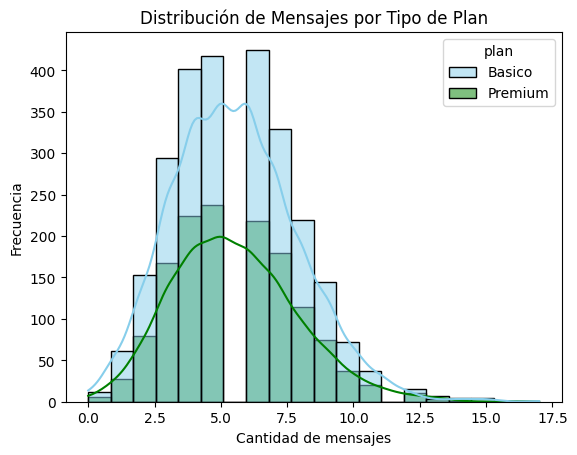

In [98]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="is_text",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20
)
plt.title("Distribución de Mensajes por Tipo de Plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()


💡Insights:
- Los usuarios Premium suelen enviar más mensajes, mostrando una cola más larga hacia valores altos.
- La distribución suele ser sesgada a la derecha, indicando que pocos usuarios envían muchísimos mensajes.

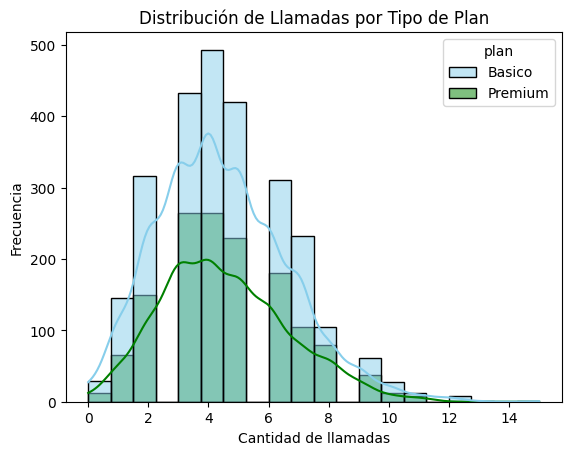

In [99]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="is_call",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20
)
plt.title("Distribución de Llamadas por Tipo de Plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()


💡Insights: 
- Los usuarios del plan Premium tienden a realizar más llamadas que los del plan Básico.
- La distribución suele ser muy sesgada a la derecha, indicando que la mayoría hace pocas llamadas y unos pocos hacen muchas.

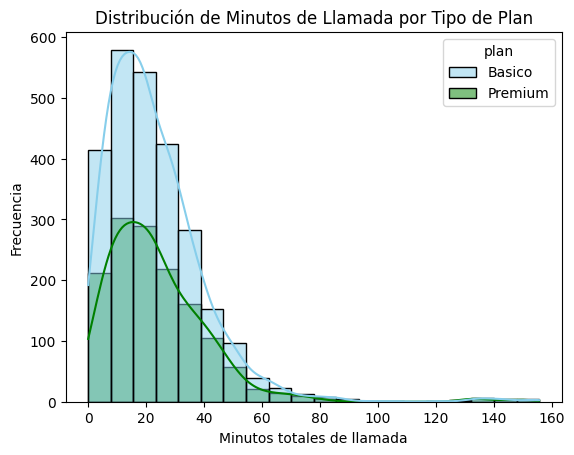

In [100]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="duration",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20
)
plt.title("Distribución de Minutos de Llamada por Tipo de Plan")
plt.xlabel("Minutos totales de llamada")
plt.ylabel("Frecuencia")
plt.show()


💡Insights: 
- Los usuarios Premium suelen acumular más minutos de llamada, lo que puede indicar mayor uso intensivo del servicio.
- La distribución casi siempre es sesgada a la derecha, con algunos usuarios que hablan muchísimo más que el promedio.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

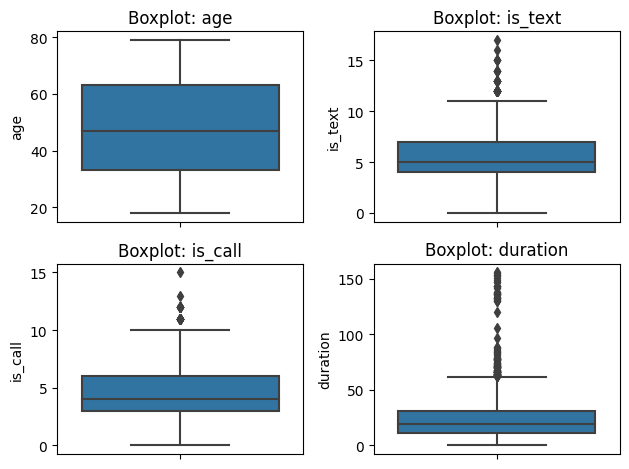

In [101]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'is_text', 'is_call', 'duration']

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()



💡Insights: 
- Age: no existe un número significativo de outliers.
- is_text: sí existen outliers.
- is_call: sí existen outliers.
- duration: sí existen outliers.
- La mayoría de los outliers aparecen solo por arriba, no por abajo, lo cual indica distribuciones sesgadas a la derecha.


In [59]:

# Calcular límites con el método IQR

columnas_limites = {}

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    columnas_limites[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lim_inf": limite_inferior,
        "lim_sup": limite_superior
    }

columnas_limites

{'age': {'Q1': 33.0,
  'Q3': 63.0,
  'IQR': 30.0,
  'lim_inf': -12.0,
  'lim_sup': 108.0},
 'is_text': {'Q1': 4.0,
  'Q3': 7.0,
  'IQR': 3.0,
  'lim_inf': -0.5,
  'lim_sup': 11.5},
 'is_call': {'Q1': 3.0,
  'Q3': 6.0,
  'IQR': 3.0,
  'lim_inf': -1.5,
  'lim_sup': 10.5},
 'duration': {'Q1': 11.12,
  'Q3': 31.415,
  'IQR': 20.295,
  'lim_inf': -19.322500000000005,
  'lim_sup': 61.8575}}

In [104]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,age,is_text,is_call,duration
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- is_text: mantener o no outliers, porqué? Sí los mantendría.
- - En plataformas de mensajería es normal que exista un grupo pequeño de heavy texters que envían muchísimos más mensajes que el resto. Estos valores altos no suelen ser errores, sino comportamientos reales de usuarios intensivos.
-- Eliminarlos podría distorsionar el entendimiento del uso real.
- is_call: mantener o no outliers, porqué? Sí los mantendría.
-- Los outliers en is_call corresponden a usuarios con un uso intensivo del servicio. No parecen errores y aportan información relevante, por lo que se recomienda conservarlos. 
- duration: mantener o no outliers, porqué? Sí los mantendría.
- Muestran un comportamiento típico de la duración de cada llamada, donde habrá usuarios que tarden mucho en sus llamadas y gente que no tanto. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [118]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row["is_call"] < 5 and row["is_text"] < 5:
        return "Bajo uso"
    elif row["is_call"] < 10 and row["is_text"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1)


In [119]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_text,is_call,duration,grupo_uso,Nivel_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [115]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row["age"] < 30:
        return "Joven"
    elif row["age"] < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(clasificar_edad, axis=1)


In [120]:
user_profile = user_profile.drop(columns=["Nivel_uso"])

In [121]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_text,is_call,duration,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

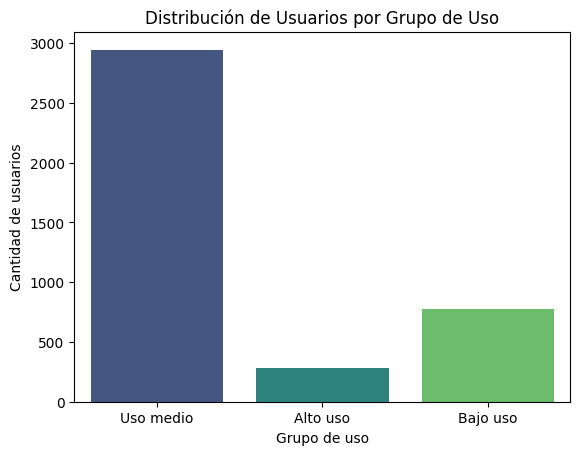

In [122]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x="grupo_uso", palette="viridis")
plt.title("Distribución de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()


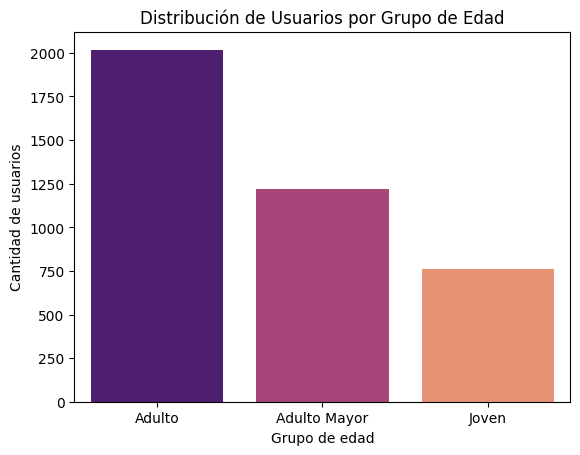

In [123]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad", palette="magma")
plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Durante la fase de limpieza se identificaron varios problemas que afectaban la calidad del dataset:
- Valores faltantes en columnas como edad y duración de llamadas.
- Registros duplicados en la tabla de uso.
- Formatos de fechas diferentes.
- Nulos e inconsistencias en la columna de 'city'.
- Nulos en las columnas de 'duration' y 'length' de la tabla 'usage'.
- Valores negativos en la columna de 'age'

🔍 **Segmentos por Edad**
Se identificaron tres grupos principales:
- Joven (<30 años):
Uso más variable, con presencia de heavy users.
Mayor afinidad a servicios digitales y mensajería.
- Adulto (30–59 años):
Es el grupo más numeroso.
Uso estable y predecible, ideal para planes estándar.
- Adulto Mayor (≥60 años):
Menor interacción general.
Uso más conservador y enfocado en llamadas.

📊 **Segmentos por Nivel de Uso**
La segmentación por comportamiento reveló tres niveles:
- Bajo uso:
Usuarios esporádicos, baja interacción en llamadas y mensajes.
- Uso medio:
La mayoría de los usuarios.
Actividad moderada y constante.
- Alto uso:
Heavy users con actividad muy por encima del promedio.
Representan un segmento pequeño pero altamente valioso.

➡️ Esto sugiere que la base de usuarios está compuesta principalmente por clientes de uso moderado, con un grupo reducido pero significativo de usuarios intensivos que podrían impulsar ingresos adicionales.

💡 **Recomendaciones**

-- Crear planes segmentados por edad y uso:
- Plan Joven+: más mensajes, datos y beneficios digitales.
- Plan Estable: para adultos con uso moderado.
- Plan Senior: para adultos mayores con necesidades básicas.
--  Ofrecer paquetes adicionales:
- Bonos de minutos para heavy callers.
- Paquetes de mensajes para heavy texters.
- Beneficios por uso recurrente.
-- Estrategias de retención:
- Identificar heavy users y ofrecerles beneficios antes de que migren.
- Programas de lealtad basados en uso.
-- Monitoreo continuo:
- Revisar mensualmente los outliers para detectar cambios en patrones.
- Ajustar límites de segmentación conforme crezca la base.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`